In [1]:
# here is how we activate an environment in our current directory
import Pkg;
Pkg.activate(@__DIR__);

# instantate this environment (download packages if you haven't)
Pkg.instantiate();

using Test
using LinearAlgebra
import ForwardDiff as FD

using LaTeXStrings
using Plots
pyplot()
PyPlot.matplotlib.rc("text", usetex = true)
PyPlot.matplotlib.rc("font", family = "Times New Roman")
PyPlot.matplotlib.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

using JupyterFormatter
enable_autoformat()

  Activating project at `~/optimal-control/code/hw0`


2-element Vector{Function}:
 force_new_fig (generic function with 1 method)
 format_current_cell (generic function with 1 method)

# Q2: Newton's Method

## Part (a): Newton's method in 1 dimension
First let's look at a nonlinear function, and label where this function is equal to 0 (a root of the function).

In [2]:
let
    x = 2:0.1:4
    y = sin.(x) .* x .^ 2
    plot(x, y, label = "function of interest")
    plot!(x, 0 * x, linestyle = :dash, color = :black, label = "")
    xlabel!(L"x")
    ylabel!(L"f(x)")
    scatter!([pi], [0], label = "zero")
end;

We are now going to use Newton's method to numerically evaluate the argument $x$ where this function is equal to zero. To make this more general, let's define a residual function,
$$ r(x) = \sin(x)x^2. $$
We want to drive this residual function to be zero (aka find a root to $r(x)$). To do this, we start with an initial guess at $x_k$, and approximate our residual function with a first-order Taylor expansion:
$$ r(x_k + \Delta x) \approx r(x_k) + \bigg[ \frac{\partial r}{\partial x}\bigg\rvert_{x_k} \bigg] \Delta x. $$ 
We now want to find the root of this linear approximation. In other words, we want to find a $\Delta x$ such that $r(x_k + \Delta x) = 0$. To do this, we simply re-arrange:
$$ \Delta x = -\bigg[ \frac{\partial r}{\partial x}\bigg\rvert_{x_k} \bigg]^{-1}r(x_k). $$ 
We can now increment our estimate of the root with the following:
$$ x_{k+1} = x_k + \Delta x$$
We have now described one step of Netwon's method. We started with an initial point, linearized the residual function, and solved for the $\Delta x$ that drove this linear approximation to zero. We keep taking Newton steps until $r(x_k)$ is close enough to zero for our purposes (usually not hard to drive below 1e-10). 


Julia tip: `x=A\b` solves linear systems of the form $Ax = b$ whether $A$ is a matrix or a scalar. 

In [3]:
function newtons_method_1d(x0::Real, residual_function::Function; max_iters = 10)
    # return the history of guesses as a vector
    X = zeros(max_iters)
    X[1] = x0

    for i = 1:max_iters
        r = residual_function(X[i])
        if abs(r) < 1e-10
            return X[1:i]
        end
        J = FD.derivative(residual_function, X[i])
        X[i+1] = X[i] - J \ r
    end
    error("did not converge")
end

newtons_method_1d (generic function with 1 method)

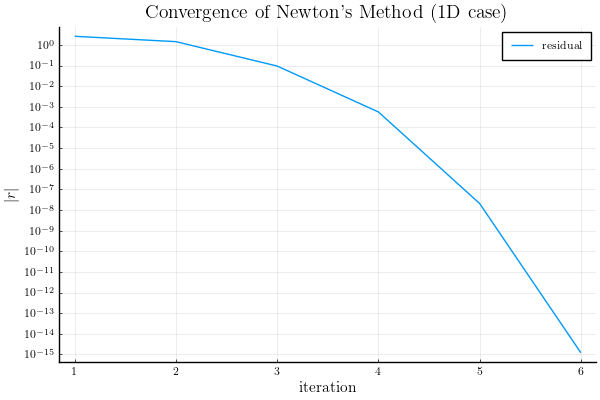

Test Summary: | Pass  Total  Time
2a            |    1      1  5.1s


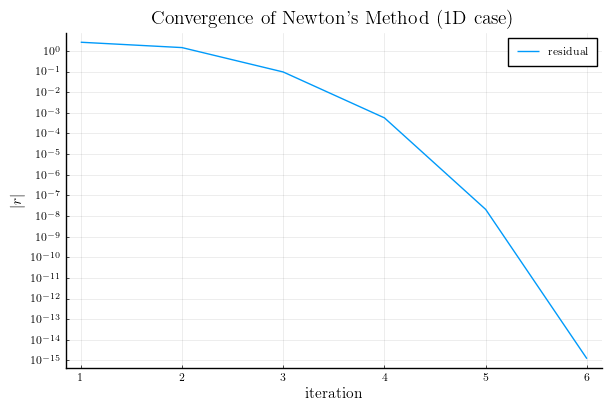

In [4]:
@testset "2a" begin
    # residual function 
    residual_fx(_x) = sin(_x) * _x^2

    X = newtons_method_1d(2.8, residual_fx; max_iters = 10)
    R = residual_fx.(X)

    @test abs(R[end]) < 1e-10

    # plotting
    display(
        plot(
            abs.(R),
            yaxis = :log,
            ylabel = L"|r|",
            xlabel = "iteration",
            yticks = [1.0 * 10.0^(-x) for x in float(15:-1:-2)],
            title = "Convergence of Newton's Method (1D case)",
            label = "residual",
        ),
    )
end;

## Part (b): Newton's method in multiple variables 
We are now going to use Newton's method to solve for the zero of a multivariate function.

In [5]:
function newtons_method(x0::Vector, residual_function::Function; max_iters = 10)
    # return the history of guesses as a vector
    X = [zeros(length(x0)) for i = 1:max_iters]
    X[1] = x0

    for i = 1:max_iters
        r = residual_function(X[i])
        if norm(r) < 1e-10
            return X[1:i]
        end
        J = FD.jacobian(residual_function, X[i])
        X[i+1] = X[i] - J \ r
    end
    error("did not converge")
end

newtons_method (generic function with 1 method)

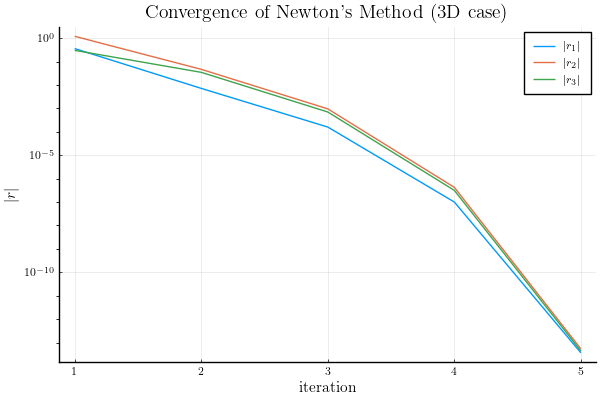

Test Summary: | Pass  Total  Time
2b            |    1      1  1.8s


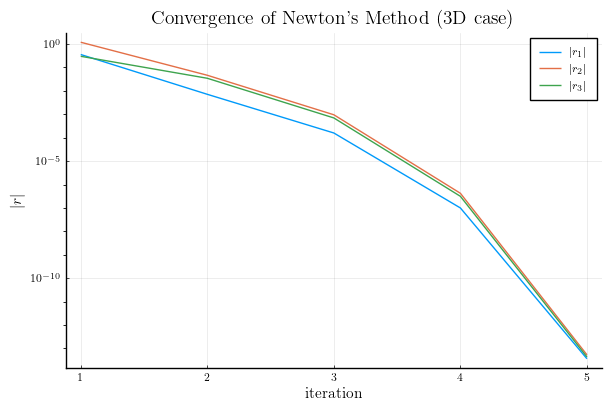

In [6]:
@testset "2b" begin
    # residual function 
    r(x) = [
        sin(x[3] + 0.3) * cos(x[2] - 0.2) - 0.3 * x[1]
        cos(x[1]) + sin(x[2]) + tan(x[3])
        3 * x[1] + 0.1 * x[2]^3
    ]

    X = newtons_method([0.1; 0.1; 0.1], r; max_iters = 10)
    R = r.(X)

    Rp = [[abs(R[i][ii]) for i = 1:length(R)] for ii = 1:3] # this gets abs of each term at each iteration

    # tests 
    @test norm(R[end]) < 1e-10

    # convergence plotting 
    plot(
        Rp[1],
        yaxis = :log,
        ylabel = L"|r|",
        xlabel = "iteration",
        # yticks = [1.0 * 10.0^(-x) for x in float(15:-1:-2)],
        title = "Convergence of Newton's Method (3D case)",
        label = L"|r_1|",
    )
    plot!(Rp[2], label = L"|r_2|")
    display(plot!(Rp[3], label = L"|r_3|"))

end;

## Part (c): Newtons method in optimization
Now let's look at how we can use Newton's method in numerical optimization. Let's start by plotting a cost function $f(x)$, where $x\in \mathbb{R}^2$.

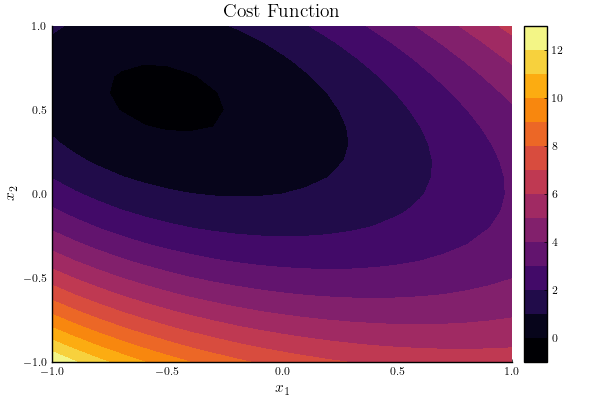

sys:1: UserWarning: The following kwargs were not used by contour: 'label'


In [7]:
let
    Q = [1.65539 2.89376; 2.89376 6.51521]
    q = [2; -3]
    f(x) = 0.5 * x' * Q * x + q' * x + exp(-1.3 * x[1] + 0.3 * x[2]^2) # cost function 
    contour(
        -1:0.1:1,
        -1:0.1:1,
        (x1, x2) -> f([x1; x2]),
        title = "Cost Function",
        xlabel = L"x_1",
        ylabel = L"x_2",
        fill = true,
    )
end

To find the minimum for this cost function $f(x)$, let's write the KKT conditions for optimality:


$$ \nabla f(x) = 0 \quad \quad \text{stationarity}, $$


which we see is just another rootfinding problem. We are now going to use Newton's method on the KKT conditions to find the $x$ in which $\nabla f(x) = 0$.  

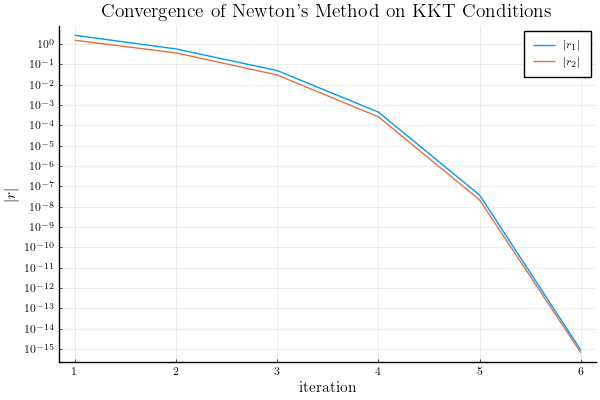

Test Summary: | Pass  Total  Time
2c            |    1      1  1.7s


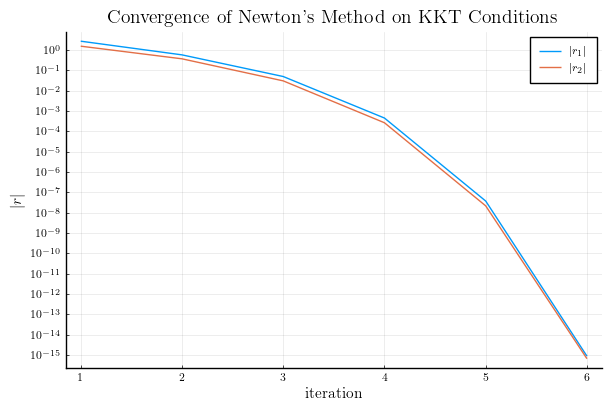

In [8]:
@testset "2c" begin
    Q = [1.65539 2.89376; 2.89376 6.51521]
    q = [2; -3]
    f(x) = 0.5 * x' * Q * x + q' * x + exp(-1.3 * x[1] + 0.3 * x[2]^2)

    function kkt_conditions(x)
        # return the stationarity condition for the cost function f (∇f(x))
        return FD.gradient(f, x)
    end

    residual_fx(_x) = kkt_conditions(_x)


    X = newtons_method(
        [-0.9512129986081451, 0.8061342694354091],
        residual_fx;
        max_iters = 10,
    )
    R = residual_fx.(X)

    Rp = [[abs(R[i][ii]) for i = 1:length(R)] for ii = 1:length(R[1])] # this gets abs of each term at each iteration

    # tests 
    @test norm(R[end]) < 1e-7

    plot(
        Rp[1],
        yaxis = :log,
        ylabel = L"|r|",
        xlabel = "iteration",
        yticks = [1.0 * 10.0^(-x) for x in float(15:-1:-2)],
        title = "Convergence of Newton's Method on KKT Conditions",
        label = L"|r_1|",
    )
    display(plot!(Rp[2], label = L"|r_2|"))

end;

## Note on Newton's method for unconstrained optimization
To solve the above problem, we used Newton's method on the following equation:

$$ \nabla f(x) = 0 \quad \quad \text{stationarity}, $$

Which results in the following Newton steps:

$$ \Delta x = - \bigg[ \frac{\partial \nabla f(x)}{x} \bigg]^{-1} \nabla f(x_k). $$

The jacobian of the gradient of $f(x)$ is the same as the hessian of $f(x)$ (write this out and convince yourself). This means we can rewrite the Newton step as the equivalent expression:

$$ \Delta x = - [\nabla^2f(x)]^{-1} \nabla f(x_k) $$

What is the interpretation of this? Well, if we take a second order Taylor series of our cost function, and minimize this quadratic approximation of our cost function, we get the following optimization problem:

$$ \min_{\Delta x} \quad \quad f(x_k) + [\nabla f(x_k)^T] \Delta x + \frac{1}{2} \Delta x^T [\nabla^2f(x_k)] \Delta x $$

Where our optimality condition is the following:

$$ \nabla f(x_k)^T +  [\nabla^2f(x_k)] \Delta x = 0 $$ 

And we can solve for $\Delta x$ with the following:

$$ \Delta x = - [\nabla^2f(x)]^{-1} \nabla f(x_k) $$

Which is our Newton step. This means that Newton's method on the stationary condition is the same as minimizing the quadratic approximation of the cost function at each iteration. 